# MMS - Analytical Test For Convergence

We consider the Stokes problem defined in the domain $\Omega := {[0,1]}^2$ by the following system of PDEs, boundary conditions, and initial conditions:
$$
\begin{cases}
  -\mu\boldsymbol{\Delta} \boldsymbol{u} + \boldsymbol{\nabla} p = \boldsymbol{f},
  \qquad&\text{in }\Omega\\
  \boldsymbol{\nabla} \cdot \boldsymbol{u} = 0,
  \qquad &\text{in }\Omega \\
  \boldsymbol{u} = \boldsymbol{u}_D \;\; &{\rm on} \ \Gamma_D \\
  (\mu\boldsymbol{\nabla} \boldsymbol{u} - p)\cdot\boldsymbol{n} = \boldsymbol{g}_N\;\;
  &{\rm on}\ \partial\Omega\setminus \Gamma_D, \\
\end{cases}
$$

In the following test case we consider $\Gamma_D = \{(x, y)\in\partial\Omega\; |\; x = 0\} \cup \{(x, y)\in\partial\Omega\; |\; y = 0\}.$


The analytical solution is:
$$
            \boldsymbol{u}(x,y) =  \begin{bmatrix}(1-\cos(\pi x))\sin(\pi y) \\ \sin(\pi x)(\cos(\pi y)-1)\end{bmatrix}
            \qquad
            p(x,y) = -\frac{1}{4}(\cos{(2\pi x)}+\cos{(2\pi y)}).
$$

The corresponding $f$, $g_{Nt}$, $g_{Nr}$ are respectively:
$$ 
            \boldsymbol{f}(x,y) = \begin{pmatrix}
            -2\pi^2 \cos(\pi x) \sin(\pi y) + \frac{1}{2}\pi \sin(2\pi x) + \pi^2 \sin(\pi y) \\[6pt]
            2\pi^2 \sin(\pi x) \cos(\pi y) + \frac{1}{2}\pi \sin(2\pi y) - \pi^2 \sin(\pi x)
            \end{pmatrix}
$$

$$
 \boldsymbol{g}_{Nt}(x, y) = \begin{pmatrix}
           -\pi \bigl(\cos(\pi x) + 1\bigr) \\[6pt]
            \frac{1}{4} \bigl(\cos(2\pi x) + \cos(2\pi y)\bigr)
            \end{pmatrix}
             
$$

$$
\boldsymbol{g}_{Nr}(x, y) = \begin{pmatrix}
            \frac{1}{4} \bigl(\cos(2\pi x) + \cos(2\pi y)\bigr) \\[6pt]
            \pi \bigl(\cos(\pi y) + 1\bigr)
            \end{pmatrix}
$$

where $\boldsymbol{g}_{Nt}$ is the Neumann condition associated with the top boundary, while $\boldsymbol{g}_{Nr}$ is the Neumann condition associated with the right boundary.




In [1]:
from problems.analytical import generate_problem
from fenics import Constant
from solvers import SolverFactory
from common import MethodType
from postprocessing import plot_combined,ConvergenceStudy,ConvergencePlotter

In [16]:
# Setting up the methods we want to test, setting up also the studies
refs = [2,4,8,15,32]
primal_methods = [MethodType.TH,MethodType.MINI,MethodType.KS]
studies = {}

In [17]:
for method in primal_methods:
    study = ConvergenceStudy(method)
    for N in refs:
        problem = generate_problem(n=N)
        solver = SolverFactory.create_solver(method)
        solution = solver.solve(problem,Constant(1.0))
        study.add_step(problem,solution,1/N)
    studies[method] = study

Solving linear variational problem.
Solving linear variational problem.
Solving linear variational problem.
Solving linear variational problem.
Solving linear variational problem.
Solving linear variational problem.
Solving linear variational problem.
Solving linear variational problem.
Solving linear variational problem.
Solving linear variational problem.
Solving linear variational problem.
Solving linear variational problem.
Solving linear variational problem.
Solving linear variational problem.
Solving linear variational problem.


In [12]:
studies[MethodType.TH]

**Convergence Study: TAYLOR-HOOD**


| $h$ | $\|u - u_h\|_{L^2}$ | EOC | $\|u - u_h\|_{H^1}$ | EOC | $\|p - p_h\|_{L^2}$ | EOC | $\|\mathbf{T} - \mathbf{T}_h\|_{L^2}$ | EOC |
|:---:|:---:|:---:|:---:|:---:|:---:|:---:|:---:|:---:|
| $5.00 \times 10^{-1}$ | $2.07 \times 10^{-2}$ | - | $3.14 \times 10^{-1}$ | - | $1.07 \times 10^{-1}$ | - | $4.73 \times 10^{-1}$ | - |
| $2.50 \times 10^{-1}$ | $2.44 \times 10^{-3}$ | 3.08 | $8.10 \times 10^{-2}$ | 1.96 | $2.42 \times 10^{-2}$ | 2.14 | $1.20 \times 10^{-1}$ | 1.97 |
| $1.25 \times 10^{-1}$ | $3.02 \times 10^{-4}$ | 3.01 | $2.04 \times 10^{-2}$ | 1.99 | $4.92 \times 10^{-3}$ | 2.30 | $3.03 \times 10^{-2}$ | 1.99 |
| $6.67 \times 10^{-2}$ | $4.59 \times 10^{-5}$ | 3.00 | $5.84 \times 10^{-3}$ | 1.99 | $1.31 \times 10^{-3}$ | 2.11 | $8.69 \times 10^{-3}$ | 1.99 |
| $3.12 \times 10^{-2}$ | $4.74 \times 10^{-6}$ | 3.00 | $1.29 \times 10^{-3}$ | 2.00 | $2.80 \times 10^{-4}$ | 2.03 | $1.92 \times 10^{-3}$ | 1.99 |

In [19]:
mixed_methods = [MethodType.AFW,MethodType.HYBRID,MethodType.RTCG]

for method in mixed_methods:
    study = ConvergenceStudy(method)
    for N in refs:
        problem = generate_problem(n=N)
        solver = SolverFactory.create_solver(method)
        solution = solver.solve(problem, Constant(1.0))
        study.add_step(problem, solution, 1/N)
    studies[method] = study

Solving linear variational problem.
Solving linear variational problem.
Solving linear variational problem.
Solving linear variational problem.
Solving linear variational problem.
Solving linear variational problem.
Solving linear variational problem.
Solving linear variational problem.
Solving linear variational problem.
Solving linear variational problem.
Solving linear variational problem.
Solving linear variational problem.
Solving linear variational problem.
Solving linear variational problem.
Solving linear variational problem.


In [20]:
studies[MethodType.AFW]

**Convergence Study: ARNOLD-FALK-WINTHER**


| $h$ | $\|u - u_h\|_{L^2}$ | EOC | $\|p - p_h\|_{L^2}$ | EOC | $\|\mathbf{T} - \mathbf{T}_h\|_{L^2}$ | EOC | $\|\mathbf{T} - \mathbf{T}_h\|_{H(\mathrm{div})}$ | EOC |
|:---:|:---:|:---:|:---:|:---:|:---:|:---:|:---:|:---:|
| $5.00 \times 10^{-1}$ | $3.95 \times 10^{-1}$ | - | $5.65 \times 10^{-1}$ | - | $1.63 \times 10^{0}$ | - | $5.67 \times 10^{0}$ | - |
| $2.50 \times 10^{-1}$ | $1.90 \times 10^{-1}$ | 1.05 | $2.02 \times 10^{-1}$ | 1.49 | $7.40 \times 10^{-1}$ | 1.14 | $2.96 \times 10^{0}$ | 0.94 |
| $1.25 \times 10^{-1}$ | $9.34 \times 10^{-2}$ | 1.03 | $6.60 \times 10^{-2}$ | 1.61 | $3.56 \times 10^{-1}$ | 1.05 | $1.50 \times 10^{0}$ | 0.99 |
| $6.67 \times 10^{-2}$ | $4.95 \times 10^{-2}$ | 1.01 | $2.58 \times 10^{-2}$ | 1.50 | $1.89 \times 10^{-1}$ | 1.01 | $8.00 \times 10^{-1}$ | 1.00 |
| $3.12 \times 10^{-2}$ | $2.32 \times 10^{-2}$ | 1.00 | $9.70 \times 10^{-3}$ | 1.29 | $8.86 \times 10^{-2}$ | 1.00 | $3.75 \times 10^{-1}$ | 1.00 |

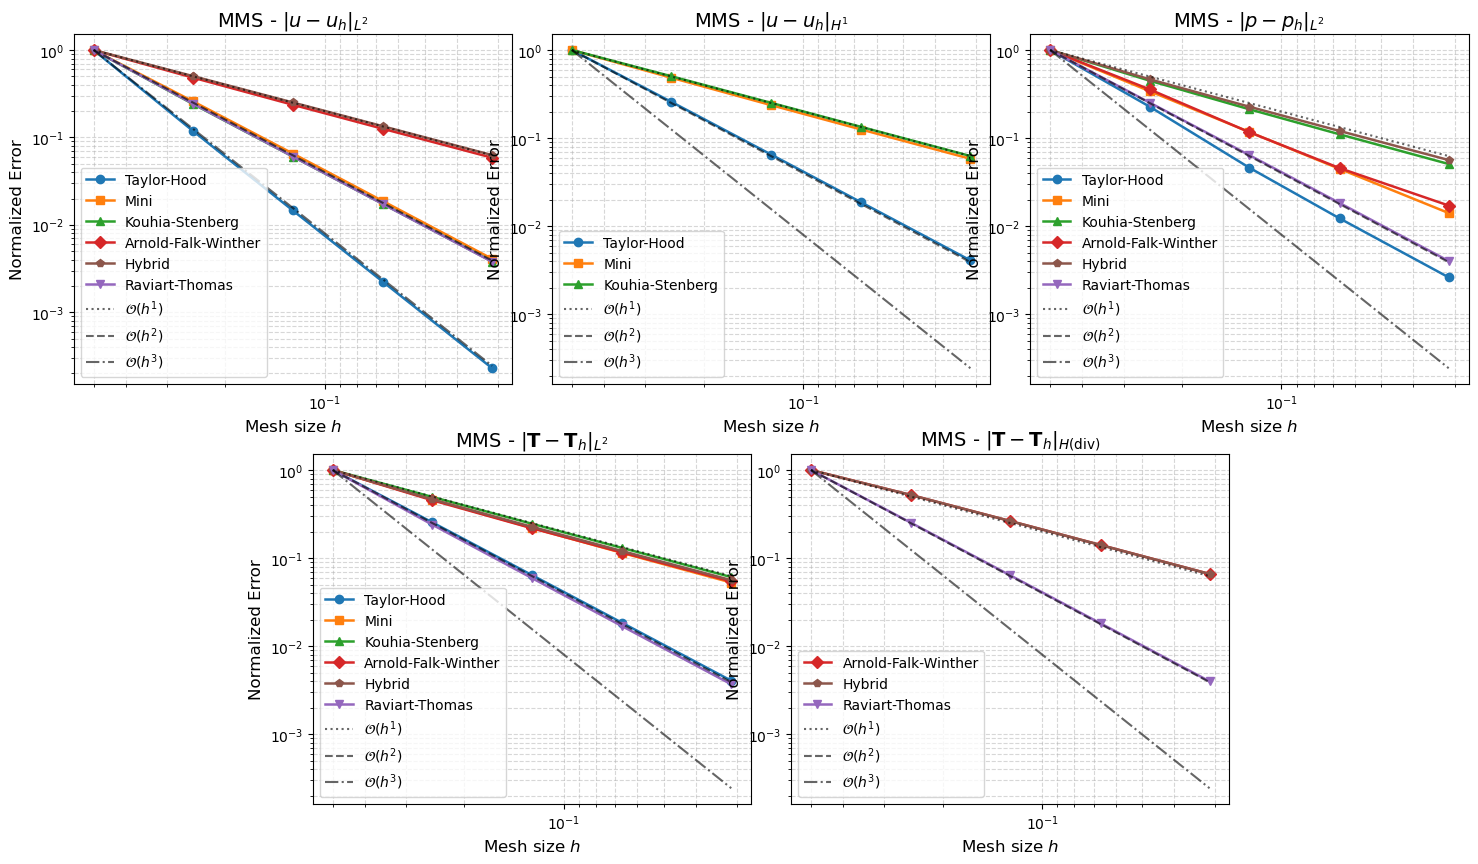

In [21]:
plotter = ConvergencePlotter(primal_methods+mixed_methods,'h',"MMS",normalized=True)

for study in studies.values():
    plotter.plot_from_study(study)

refs = [2,4,8,16,32]
h_refs = [1/n for n in refs]

for error in plotter.active_norms:
    for degree in [1,2,3]:
        plotter.add_reference_slope(error,h_refs,degree)